# HRM v1 on Held-Out MazeHard Test Mazes

This notebook restores a checkpointed HRM v1 executor from an inference-scoped figure config, runs it on real MazeHard test data from the processed corpus, captures the evaluation trace, and renders the built-in `evolution` and `overlay` figures.

Change the inference config path or values if you want to inspect a different checkpoint or test slice.


In [1]:
import sys
import tomllib
from dataclasses import replace
from pathlib import Path

import torch
from torch import device as Device
from ehc_sn.eval.contracts import EvaluationTraceRequest
from ehc_sn.figures import FigureContext, render
from ehc_sn.lightning.hrm.hrm_v1 import HRMV1ModelConfig, HRMV1TrainingModel
from ehc_sn.tasks.mazehard.providers import MazeHardReplayProvider
from ehc_sn.tasks.mazehard.runtime import PATH_ID
from ehc_sn.types import Batch

In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").exists() and (candidate / "config").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root from the current working directory."
    )

In [3]:
ROOT = find_repo_root(Path.cwd().resolve())
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

## Configure the Run

We keep the notebook aligned with the training entrypoint by reading the same TOML file, then extracting just the model-owned config needed by the Lightning module.

The dataset comes from the processed MazeHard task corpus, and the checkpoint comes from the debug HRM v1 run.


In [4]:
TRAIN_CONFIG_PATH = ROOT / "config/training/hrm-v1-debug.toml"
CHECKPOINT_PATH = ROOT / "checkpoints/hrm-v1/last.ckpt"
DATASET_PATH = ROOT / "data/processed/mazehard/default/v1"

SPLIT = "test"
N_CASES = 5
SAMPLE_IDX = 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not TRAIN_CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing training config: {TRAIN_CONFIG_PATH}")
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Missing checkpoint: {CHECKPOINT_PATH}")
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing dataset root: {DATASET_PATH}")

{
    "device": str(DEVICE),
    "checkpoint": str(CHECKPOINT_PATH.relative_to(ROOT)),
    "dataset": str(DATASET_PATH.relative_to(ROOT)),
}

{'device': 'cuda',
 'checkpoint': 'checkpoints/hrm-v1/last.ckpt',
 'dataset': 'data/processed/mazehard/default/v1'}

In [5]:
def build_hrm_v1_model_config(defaults: dict) -> HRMV1ModelConfig:
    return HRMV1ModelConfig.model_validate(
        {
            "model_config_path": defaults["model_config_path"],
            "adapter": defaults["adapter"],
            "controller": defaults["controller"],
            "objective": defaults["objective"],
            "optimizer": defaults["optimizer"],
            "scheduler": defaults["scheduler"],
            "runtime": defaults["runtime"],
            "global_batch_size": defaults["global_batch_size"],
        }
    )


def move_batch_to_device(batch: Batch, device: Device) -> Batch:
    return {
        key: value.to(device) if hasattr(value, "to") else value
        for key, value in batch.items()
    }

## Restore the Checkpointed Model

This cell restores the full Lightning module, including the MazeHard bridge weights, and moves it to the active device for inference.


In [6]:
train_defaults = tomllib.load(TRAIN_CONFIG_PATH.open("rb"))
model_config = build_hrm_v1_model_config(train_defaults)

module = HRMV1TrainingModel.load_from_checkpoint(
    checkpoint_path=str(CHECKPOINT_PATH),
    config=model_config,
    map_location="cpu",
)
module.eval()
module.to(DEVICE)

HRMV1TrainingModel(
  (model): HRModelV1(
    (pfc): PFCModel(
      (high_level): HighLvRModule(
        (cortex): TransformerStack(
          (layers): ModuleList(
            (0-3): 4 x TransformerBlock(
              (self_attn): Attention(
                (in_proj): Linear(in_features=512, out_features=1536, bias=False)
                (out_proj): Linear(in_features=512, out_features=512, bias=False)
              )
              (mlp): SwiGLU(
                (gate_up_proj): Linear(in_features=512, out_features=3072, bias=False)
                (down_proj): Linear(in_features=1536, out_features=512, bias=False)
              )
            )
          )
        )
      )
      (low_level): LowLvRModule(
        (cortex): TransformerStack(
          (layers): ModuleList(
            (0-3): 4 x TransformerBlock(
              (self_attn): Attention(
                (in_proj): Linear(in_features=512, out_features=1536, bias=False)
                (out_proj): Linear(in_features=512, o

## Load a Held-Out Batch and Capture the Figure Trace

We use the MazeHard replay provider so the notebook follows the same processed-data evaluation path used elsewhere in the codebase.

The trace request asks for the model prediction overlay, the ACT halted signal, and the static input ids. We also attach the ground-truth solution overlay in trace metadata so the built-in figures can compare prediction vs target directly.


In [7]:
provider = MazeHardReplayProvider(
    dataset_path=str(DATASET_PATH),
    split=SPLIT,
    batch_size=N_CASES,
    n_cases=N_CASES,
)
case = next(provider.provide_cases(max_batches=1))
case = replace(case, batch=move_batch_to_device(case.batch, DEVICE))

requested_trace_keys = {"act/halted", "pred/solution_overlay", "input_ids"}
module.set_eval_trace_keys(requested_trace_keys)

trace_request = EvaluationTraceRequest(
    trace_spec=module.trace_spec,
    trace_meta={
        "target": {
            "solution_overlay": (case.batch["labels"] == PATH_ID)
            .to(torch.uint8)
            .detach()
            .cpu(),
        },
    },
)

with torch.inference_mode():
    result = module.execute_evaluation_batch(case, trace_request=trace_request)

trace = result.trace
if trace is None:
    raise RuntimeError("The evaluation trace was not captured.")

sample_ids = list(getattr(case.source_context, "sample_ids", ()))

{
    "case_id": result.case_id,
    "sample_ids": sample_ids,
    "input_ids_shape": tuple(trace.get_meta_path("input_ids").shape),
    "halted_shape": tuple(trace.get("act/halted").shape),
    "pred_overlay_shape": tuple(trace.get("pred/solution_overlay").shape),
}

{'case_id': 'mazehard-test-0000',
 'sample_ids': ['mazehard-test-000001',
  'mazehard-test-000002',
  'mazehard-test-000003',
  'mazehard-test-000004',
  'mazehard-test-000005'],
 'input_ids_shape': (5, 900),
 'halted_shape': (16, 5),
 'pred_overlay_shape': (16, 5, 900)}

## Figure 1: Prediction Evolution for One Test Maze

This figure shows one held-out maze: the ground-truth path on the left and the model's path prediction over recurrent evaluation steps on the right.


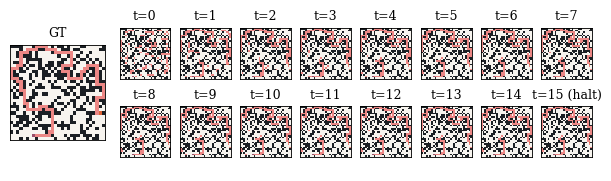

In [10]:
render("evolution", trace, FigureContext(sample_idx=SAMPLE_IDX))

## Figure 2: Ground Truth vs Final Predicted Overlay

This figure compares the final predicted overlay against the ground-truth solution overlay for the held-out batch.


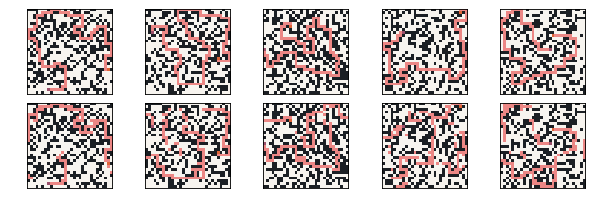

In [11]:
render("overlay", trace, FigureContext(sample_idx=0, max_items=N_CASES))